# Hoeffding Inequality doesn't apply

**Exercise 1.10**

Here is an experiment that illustrates the difference between a single bin and multiple bins. Run a computer simulation for flipping 1,000 fair coins. Flip each coin independently 10 times. Let's focus on 3 coins as follows: $c_1$ is the first coin flipped; $c_{\text{rand}}$ is a coin you choose at random; $c_{\text{min}}$ is the coin that had the minimum frequency of heads (pick the earlier one in case of a tie). Let $\nu_1$, $\nu_{\text{rand}}$ and $\nu_{\text{min}}$ be the fraction of heads you obtain for the respective three coins.

(a) What is $\mu$ for the three coins selected?

(b) Repeat this entire experiment a large number of times (e.g., 100,000 runs of the entire experiment) to get several instances of $\nu_1$, $\nu_{\text{rand}}$ and $\nu_{\text{min}}$ and plot the histograms of the distributions of $\nu_1$, $\nu_{\text{rand}}$ and $\nu_{\text{min}}$. Notice that which coins end up being $c_{\text{rand}}$ and $c_{\text{min}}$ may differ from one run to another.

(c) Using (b), plot estimates for $\mathbb{P}[|\nu - \mu| > \epsilon]$ as a function of $\epsilon$, together with the Hoeffding bound $2e^{-2\epsilon^2N}$ (on the same graph).

(d) Which coins obey the Hoeffding bound, and which ones do not? Explain why.

(e) Relate part (d) to the multiple bins in Figure 1.10.

<>:75: SyntaxWarning: "\e" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\e"? A raw string is also an option.
<>:76: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:75: SyntaxWarning: "\e" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\e"? A raw string is also an option.
<>:76: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
C:\Users\Luis Andres\AppData\Local\Temp\ipykernel_16144\2968011473.py:75: SyntaxWarning: "\e" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\e"? A raw string is also an option.
  plt.xlabel('$\epsilon$ (Tolerance)')
C:\Users\Luis Andres\AppData\Local\Temp\ipykernel_16144\2968011473.py:76: SyntaxWarning: "\m" is an invalid escape sequence.

Simulating 100000 runs of 1000 coins flipped 10 times each...


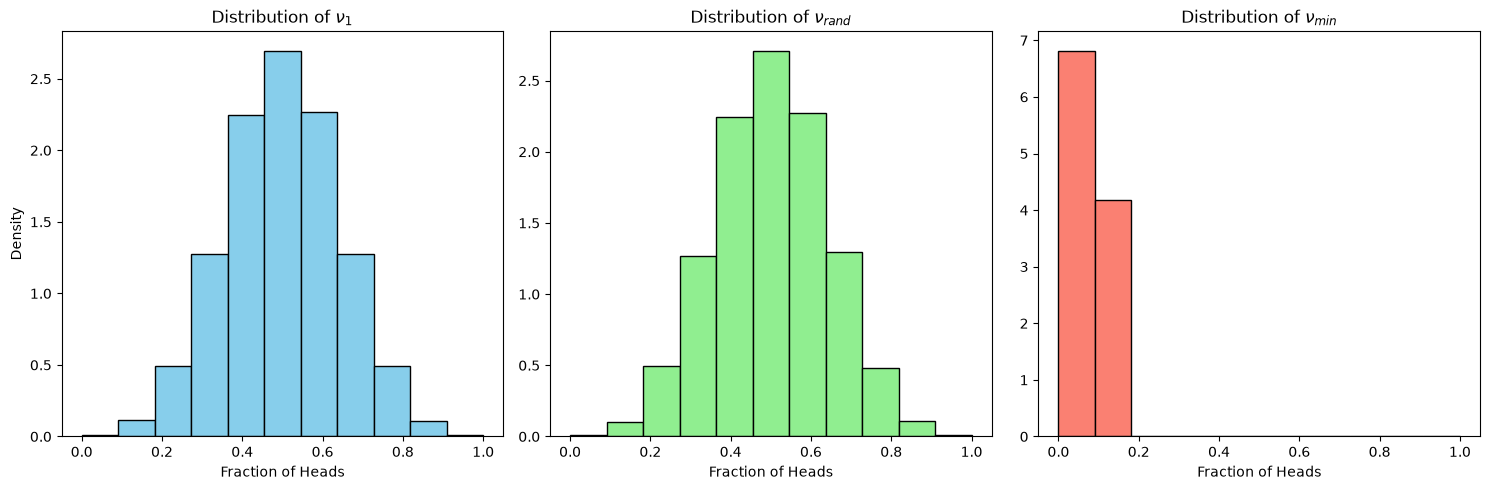

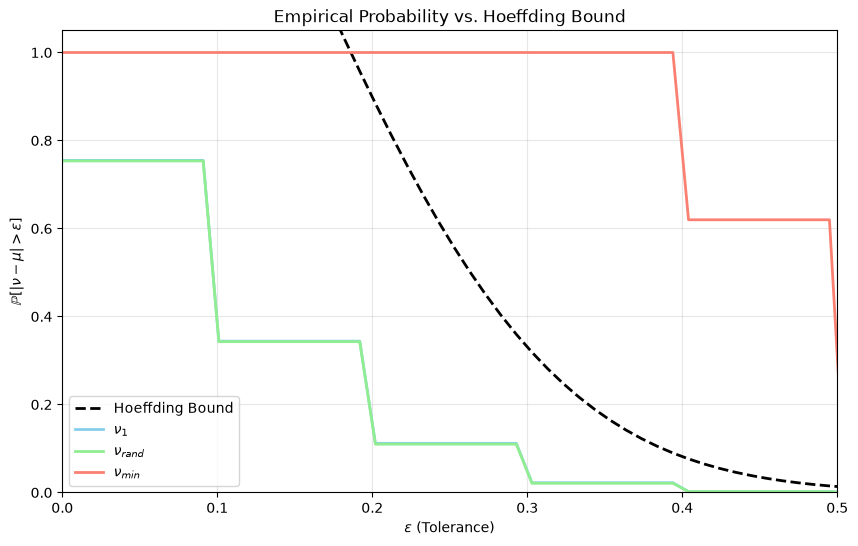

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# --- Experiment Parameters ---
N = 10               # Number of flips per coin
num_coins = 1000     # Number of coins per run
num_runs = 100000    # Number of times to repeat the experiment
mu = 0.5             # True probability of heads (Answer for part A)

print(f"Simulating {num_runs} runs of {num_coins} coins flipped {N} times each...")

# --- Part (b): Run the Simulation ---
# Using the binomial distribution simulates the sum of N flips directly for efficiency.
# 'heads' will be a matrix of shape (100000, 1000) containing the number of heads.
heads = np.random.binomial(n=N, p=mu, size=(num_runs, num_coins))

# 1. c_1: The first coin flipped (index 0)
nu_1 = heads[:, 0] / N

# 2. c_rand: A coin chosen at random
# Generate a random column index for each of the 100,000 rows
rand_indices = np.random.randint(0, num_coins, size=num_runs)
nu_rand = heads[np.arange(num_runs), rand_indices] / N

# 3. c_min: The coin with the minimum frequency of heads
# Taking the minimum across axis 1 (the 1000 coins) finds this for every run
nu_min = np.min(heads, axis=1) / N

# Plotting histograms
plt.figure(figsize=(15, 5))

# Histogram for nu_1
plt.subplot(1, 3, 1)
plt.hist(nu_1, bins=11, range=(0, 1), density=True, color='skyblue', edgecolor='black')
plt.title('Distribution of $\\nu_1$')
plt.xlabel('Fraction of Heads')
plt.ylabel('Density')

# Histogram for nu_rand
plt.subplot(1, 3, 2)
plt.hist(nu_rand, bins=11, range=(0, 1), density=True, color='lightgreen', edgecolor='black')
plt.title('Distribution of $\\nu_{rand}$')
plt.xlabel('Fraction of Heads')

# Histogram for nu_min
plt.subplot(1, 3, 3)
plt.hist(nu_min, bins=11, range=(0, 1), density=True, color='salmon', edgecolor='black')
plt.title('Distribution of $\\nu_{min}$')
plt.xlabel('Fraction of Heads')

plt.tight_layout()
plt.show()


# --- Part (c): Hoeffding Bound Estimation ---
# Epsilon values from 0 to 1
epsilons = np.linspace(0, 1, 100)

# Theoretical Hoeffding Bound: 2 * e^(-2 * epsilon^2 * N)
hoeffding_bound = 2 * np.exp(-2 * (epsilons**2) * N)

# Calculate empirical probability P[|nu - mu| > epsilon] for each epsilon
p_nu_1 = np.array([np.mean(np.abs(nu_1 - mu) > eps) for eps in epsilons])
p_nu_rand = np.array([np.mean(np.abs(nu_rand - mu) > eps) for eps in epsilons])
p_nu_min = np.array([np.mean(np.abs(nu_min - mu) > eps) for eps in epsilons])

# Plotting the bounds
plt.figure(figsize=(10, 6))
plt.plot(epsilons, hoeffding_bound, label='Hoeffding Bound', color='black', linewidth=2, linestyle='--')
plt.plot(epsilons, p_nu_1, label='$\\nu_1$', color='skyblue', linewidth=2)
plt.plot(epsilons, p_nu_rand, label='$\\nu_{rand}$', color='lightgreen', linewidth=2)
plt.plot(epsilons, p_nu_min, label='$\\nu_{min}$', color='salmon', linewidth=2)

plt.title('Empirical Probability vs. Hoeffding Bound')
plt.xlabel('$\epsilon$ (Tolerance)')
plt.ylabel('$\mathbb{P}[|\\nu - \mu| > \epsilon]$')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xlim(0, 0.5) # Zooming in on the relevant part of the x-axis
plt.ylim(0, 1.05)
plt.show()